In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('C:/Users/silve/Documents/DS_TermP_Team1/hotel_bookings.csv')
print(df.shape)

(119390, 32)


In [5]:
print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [7]:
# 수치형 / 범주형 / 이진 변수 구분
print("수치형 변수:", df.select_dtypes(include='number').columns.tolist())
print("\n범주형 변수:", df.select_dtypes(include='object').columns.tolist())
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
print("\n이진 변수:", binary_cols)

수치형 변수: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

범주형 변수: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

이진 변수: ['hotel', 'is_canceled', 'is_repeated_guest']


In [8]:
# 결측치 확인
missing = df.isnull().sum()
missing_ratio = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측치 수': missing, '비율(%)': missing_ratio})
print(missing_df[missing_df['결측치 수'] > 0])

           결측치 수  비율(%)
children       4   0.00
country      488   0.41
agent      16340  13.69
company   112593  94.31


In [11]:
# 기초 통계량
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


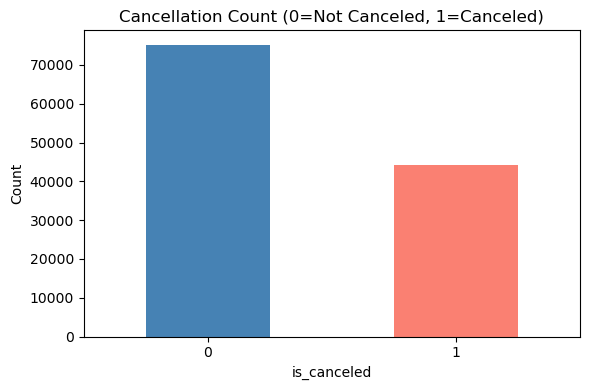

In [12]:
import os
os.makedirs('../reports/figures', exist_ok=True)

# 취소 비율 그래프
plt.figure(figsize=(6,4))
df['is_canceled'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Cancellation Count (0=Not Canceled, 1=Canceled)')
plt.xlabel('is_canceled')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/cancel_ratio.png')
plt.show()

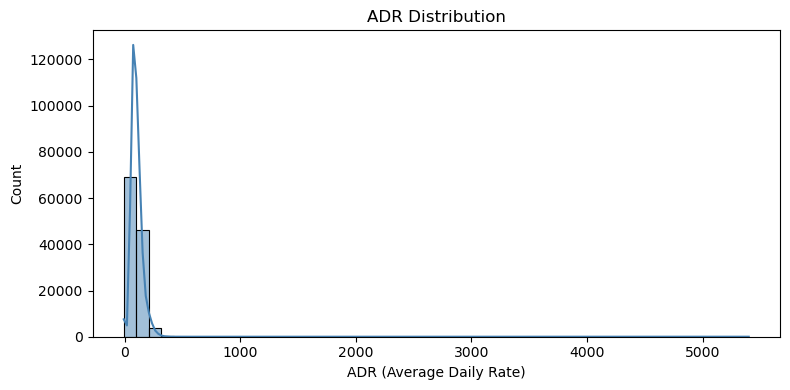

In [13]:
# ADR 분포 그래프
plt.figure(figsize=(8,4))
sns.histplot(df['adr'], bins=50, kde=True, color='steelblue')
plt.title('ADR Distribution')
plt.xlabel('ADR (Average Daily Rate)')
plt.tight_layout()
plt.savefig('../reports/figures/adr_distribution.png')
plt.show()

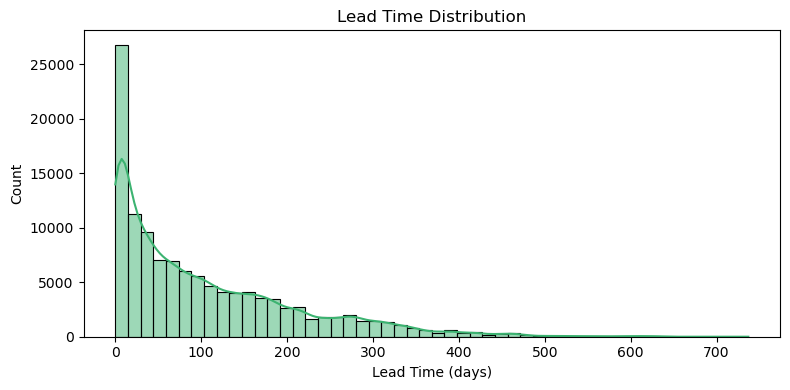

In [14]:
# lead_time 분포 그래프
plt.figure(figsize=(8,4))
sns.histplot(df['lead_time'], bins=50, kde=True, color='mediumseagreen')
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (days)')
plt.tight_layout()
plt.savefig('../reports/figures/lead_time_distribution.png')
plt.show()

In [15]:
# 이상치 확인
print("ADR 최대값:", df['adr'].max())
print("ADR 0 이하인 행 수:", (df['adr'] <= 0).sum())

zero_guests = df[(df['adults']==0) & (df['children']==0) & (df['babies']==0)]
print("total guests가 0인 행 수:", len(zero_guests))

ADR 최대값: 5400.0
ADR 0 이하인 행 수: 1960
total guests가 0인 행 수: 180
